# 02 · D3TaLES 还原电位数据清洗

本 Notebook 根据第一阶段审计结果生成清洗后的建模数据。规则是：保留还原电位非空的中性分子；删除无效 SMILES；同一 Canonical SMILES 的目标极差不超过 0.05 eV 时取均值，超过 0.05 eV 时将整组作为冲突记录排除。

## 单元格 1：导入依赖并定位项目目录

作用：导入路径、哈希、JSON、数据分析、绘图和 RDKit 工具，并自动定位项目根目录。

In [1]:
# 标准库：路径、文件哈希、JSON 和环境版本
from pathlib import Path
import hashlib
import json
import platform

# 数据分析与绘图
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 分子解析、Canonical SMILES 和 Murcko scaffold
from rdkit import Chem, rdBase
from rdkit.Chem.Scaffolds import MurckoScaffold

# 支持从项目根目录或 notebooks 目录启动 Notebook
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('RDKit:', rdBase.rdkitVersion)
print('项目根目录:', PROJECT_ROOT)

Python: 3.10.21
pandas: 2.3.3
RDKit: 2022.09.5
项目根目录: E:\desktop\myJCIM


## 单元格 2：设置路径和清洗参数

作用：声明原始数据、清洗结果和报告的位置，并把重复组容许极差固定为 0.05 eV。原始 CSV 不会被修改。

In [2]:
# 输入文件及输出目录
RAW_CSV = PROJECT_ROOT / 'data' / 'raw' / 'd3tales_public.csv'
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DATA_DIR = PROJECT_ROOT / 'reports' / 'data'
REPORT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'

# 第一阶段已确认的原始文件校验值，防止误用其他版本
EXPECTED_SHA256 = '40dc15b8dd00800a23b4ad6f57456634c8163a237cd7cb32aafa9addb7db492d'

# 数据驱动的去重规则：不超过该极差的重复组取平均，超过则排除整组
DUPLICATE_TOLERANCE_EV = 0.05
DATASET_VERSION = 'D3TaLES-Reduction-v1'

# 只创建输出目录，不创建或覆盖任何结果文件
for output_dir in [INTERIM_DIR, PROCESSED_DIR, REPORT_DATA_DIR, REPORT_FIGURE_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

if not RAW_CSV.exists():
    raise FileNotFoundError(f'没有找到原始数据: {RAW_CSV}')

print('原始数据:', RAW_CSV)
print('重复组容许极差(eV):', DUPLICATE_TOLERANCE_EV)
print('数据集版本:', DATASET_VERSION)

原始数据: E:\desktop\myJCIM\data\raw\d3tales_public.csv
重复组容许极差(eV): 0.05
数据集版本: D3TaLES-Reduction-v1


## 单元格 3：验证原始文件并读取数据

作用：重新计算 SHA256 并与第一次审计的文件版本比较，然后读取 CSV 和检查关键字段。校验失败时停止，避免对错误版本进行清洗。

In [3]:
# 分块计算 SHA256，避免一次性读取整个二进制文件
sha256 = hashlib.sha256()
with RAW_CSV.open('rb') as file_handle:
    for chunk in iter(lambda: file_handle.read(1024 * 1024), b''):
        sha256.update(chunk)
raw_sha256 = sha256.hexdigest()

assert raw_sha256 == EXPECTED_SHA256, (
    '原始CSV与审计阶段不是同一版本，请停止运行并检查文件。'
)

# low_memory=False 减少混合类型推断警告
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
REQUIRED_COLUMNS = [
    '_id', 'smiles', 'source_group', 'groundState_charge', 'reduction_potential'
]
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df_raw.columns))
assert not missing_columns, f'缺少关键字段: {missing_columns}'

print('SHA256检查通过:', raw_sha256)
print('原始数据形状:', df_raw.shape)

SHA256检查通过: 40dc15b8dd00800a23b4ad6f57456634c8163a237cd7cb32aafa9addb7db492d
原始数据形状: (35777, 98)


## 单元格 4：筛选目标非空、中性且 SMILES 有效的分子

作用：建立正式清洗候选集，并生成 Canonical SMILES。每一步的样本变化都会被记录。

In [4]:
# 将 SMILES 标准化为保留立体化学信息的 Canonical SMILES
def to_canonical_smiles(smiles):
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return None
    return Chem.MolToSmiles(molecule, canonical=True, isomericSmiles=True)

# 依次应用主任务标签、中性电荷和 SMILES 有效性筛选
df_target = df_raw.loc[df_raw['reduction_potential'].notna()].copy()
df_neutral = df_target.loc[df_target['groundState_charge'].eq(0)].copy()
df_neutral['canonical_smiles'] = df_neutral['smiles'].map(to_canonical_smiles)
df_valid = df_neutral.loc[df_neutral['canonical_smiles'].notna()].copy()

data_flow = pd.DataFrame([
    {'step': 'raw_rows', 'remaining': len(df_raw)},
    {'step': 'reduction_potential_not_null', 'remaining': len(df_target)},
    {'step': 'neutral_ground_state', 'remaining': len(df_neutral)},
    {'step': 'valid_smiles', 'remaining': len(df_valid)},
])
data_flow['removed_from_previous'] = (
    data_flow['remaining'].shift(1) - data_flow['remaining']
).fillna(0).astype(int)

data_flow

,step,remaining,removed_from_previous
0,raw_rows,35777,0
1,reduction_potential_not_null,30356,5421
2,neutral_ground_state,30145,211
3,valid_smiles,30145,0


## 单元格 5：比较不同去重阈值的影响

作用：重新计算重复组极差，并展示不同阈值下会接受或排除多少重复组。正式规则仍固定为 0.05 eV，此表用于记录规则的敏感性。

In [5]:
# 每个 Canonical SMILES 形成一个分组，并统计组内目标差异
group_stats = (
    df_valid.groupby('canonical_smiles', as_index=False)
    .agg(
        record_count=('reduction_potential', 'size'),
        target_mean=('reduction_potential', 'mean'),
        target_std=('reduction_potential', 'std'),
        target_min=('reduction_potential', 'min'),
        target_max=('reduction_potential', 'max'),
    )
)
group_stats['target_range'] = group_stats['target_max'] - group_stats['target_min']
duplicate_stats = group_stats.loc[group_stats['record_count'] > 1].copy()

# 比较多个候选阈值，只统计重复组，不更改正式参数
threshold_rows = []
for threshold in [0.00, 0.01, 0.02, 0.05, 0.10]:
    accepted = duplicate_stats['target_range'].le(threshold)
    threshold_rows.append({
        'threshold_eV': threshold,
        'accepted_duplicate_groups': int(accepted.sum()),
        'excluded_conflict_groups': int((~accepted).sum()),
    })

threshold_comparison = pd.DataFrame(threshold_rows)
threshold_comparison

,threshold_eV,accepted_duplicate_groups,excluded_conflict_groups
0,0.00,0,27
1,0.01,3,24
2,0.02,6,21
3,0.05,12,15
4,0.10,18,9


## 单元格 6：给每个重复组分配处理决定

作用：将目标极差不超过 0.05 eV 的重复组标记为“取均值”，将超过阈值的组标记为“冲突排除”，并显示具体数量。

In [6]:
# 浮点数计算可能产生极小误差，因此加 1e-12 保证边界值判断稳定
within_tolerance = duplicate_stats['target_range'].le(DUPLICATE_TOLERANCE_EV + 1e-12)
duplicate_stats['decision'] = np.where(
    within_tolerance,
    'average_duplicate',
    'exclude_conflict',
)

conflict_smiles = set(
    duplicate_stats.loc[duplicate_stats['decision'].eq('exclude_conflict'), 'canonical_smiles']
)

decision_summary = duplicate_stats['decision'].value_counts().rename_axis('decision').to_frame('groups')
display(decision_summary)
duplicate_stats.sort_values('target_range', ascending=False).head(30)

,groups
decision,
exclude_conflict,15
average_duplicate,12


,canonical_smiles,record_count,target_mean,target_std,target_min,target_max,target_range,decision
17461,C[C@@H]1[C@H](C)N(S(=O)(=O)CCc2ccccc2)CCS1(=O)=O,2,6.0775,0.859135,5.470,6.685,1.215,exclude_conflict
17302,C[C@@H]1CN([C@@H](NC(=O)c2ccco2)C(Cl)(Cl)Cl)C[...,2,6.6360,0.629325,6.191,7.081,0.890,exclude_conflict
16686,C[C@@H](NC(=O)[C@H](C)c1cccs1)c1ccc(Br)cc1,2,6.1350,0.554372,5.743,6.527,0.784,exclude_conflict
17931,C[C@H](NC(=O)Nc1ccccc1)C(=O)NC[C@H](C)Oc1ccccc1,2,5.2580,0.231931,5.094,5.422,0.328,exclude_conflict
18203,C[C@H]([C@H](C)S(C)(=O)=O)N(C)C(=O)c1cc(Cl)c2c...,2,6.5385,0.178898,6.412,6.665,0.253,exclude_conflict
21670,Cc1cccc(C)c1NC(=O)COC(=O)[C@H]1[C@@H]2C[C@@H]3...,2,5.9215,0.160513,5.808,6.035,0.227,exclude_conflict
17458,C[C@@H]1[C@H](C)CCC[C@H]1NC(=O)[C@@H](C)OC(=O)...,2,5.9750,0.130108,5.883,6.067,0.184,exclude_conflict
17460,C[C@@H]1[C@H](C)CCC[C@H]1n1c(CCl)nc2cccnc21,2,7.1565,0.112430,7.077,7.236,0.159,exclude_conflict
10419,CNC(=O)c1cccc(NCC(=O)N2[C@H](C)CCC[C@@H]2C)c1C,2,5.7915,0.106773,5.716,5.867,0.151,exclude_conflict
657,C=CCOc1c(CN2C[C@@H](C)S[C@@H](C)C2)c(C)nn1C,2,7.1095,0.070004,7.060,7.159,0.099,exclude_conflict


## 单元格 7：保存被排除的冲突记录

作用：提取所有冲突重复组的原始记录，并附上组内统计信息。它们不会进入建模数据，但会被保存以保证清洗过程可追溯。

In [7]:
# 保留冲突记录的原始ID、SMILES、来源和目标值，并合并组内统计
conflict_rows = (
    df_valid.loc[df_valid['canonical_smiles'].isin(conflict_smiles), [
        '_id', 'smiles', 'canonical_smiles', 'source_group',
        'groundState_charge', 'reduction_potential'
    ]]
    .merge(
        duplicate_stats[[
            'canonical_smiles', 'record_count', 'target_min',
            'target_max', 'target_range', 'decision'
        ]],
        on='canonical_smiles',
        how='left',
        validate='many_to_one',
    )
    .sort_values(['target_range', 'canonical_smiles'], ascending=[False, True])
)

print('冲突重复组:', len(conflict_smiles))
print('被排除的原始记录:', len(conflict_rows))
conflict_rows.head(20)

冲突重复组: 15
被排除的原始记录: 31


,_id,smiles,canonical_smiles,source_group,groundState_charge,reduction_potential,record_count,target_min,target_max,target_range,decision
4,81GXPC,C[C@H]1[C@@H](C)S(=O)(=O)CCN1S(=O)(=O)CCc1ccccc1,C[C@@H]1[C@H](C)N(S(=O)(=O)CCc2ccccc2)CCS1(=O)=O,Zinc,0.0,6.685,2,5.470,6.685,1.215,exclude_conflict
30,81UBMI,C[C@@H]1[C@H](C)N(S(=O)(=O)CCc2ccccc2)CCS1(=O)=O,C[C@@H]1[C@H](C)N(S(=O)(=O)CCc2ccccc2)CCS1(=O)=O,Zinc,0.0,5.470,2,5.470,6.685,1.215,exclude_conflict
6,06OLDZ,C[C@H]1CN([C@@H](NC(=O)c2ccco2)C(Cl)(Cl)Cl)C[C...,C[C@@H]1CN([C@@H](NC(=O)c2ccco2)C(Cl)(Cl)Cl)C[...,Risko,0.0,6.191,2,6.191,7.081,0.890,exclude_conflict
18,06RJEE,C[C@@H]1CN([C@@H](NC(=O)c2ccco2)C(Cl)(Cl)Cl)C[...,C[C@@H]1CN([C@@H](NC(=O)c2ccco2)C(Cl)(Cl)Cl)C[...,Zinc,0.0,7.081,2,6.191,7.081,0.890,exclude_conflict
16,06LEWD,C[C@@H](C(=O)N[C@H](C)c1ccc(Br)cc1)c1cccs1,C[C@@H](NC(=O)[C@H](C)c1cccs1)c1ccc(Br)cc1,Risko,0.0,5.743,2,5.743,6.527,0.784,exclude_conflict
29,06JWMI,C[C@@H](NC(=O)[C@H](C)c1cccs1)c1ccc(Br)cc1,C[C@@H](NC(=O)[C@H](C)c1cccs1)c1ccc(Br)cc1,Zinc,0.0,6.527,2,5.743,6.527,0.784,exclude_conflict
14,06SMTU,C[C@@H](CNC(=O)[C@H](C)NC(=O)Nc1ccccc1)Oc1ccccc1,C[C@H](NC(=O)Nc1ccccc1)C(=O)NC[C@H](C)Oc1ccccc1,Risko,0.0,5.094,2,5.094,5.422,0.328,exclude_conflict
27,06QXYA,C[C@H](NC(=O)Nc1ccccc1)C(=O)NC[C@H](C)Oc1ccccc1,C[C@H](NC(=O)Nc1ccccc1)C(=O)NC[C@H](C)Oc1ccccc1,Zinc,0.0,5.422,2,5.094,5.422,0.328,exclude_conflict
13,06TTGF,C[C@@H]([C@@H](C)N(C)C(=O)c1cc(Cl)c2ccccc2c1O)...,C[C@H]([C@H](C)S(C)(=O)=O)N(C)C(=O)c1cc(Cl)c2c...,Risko,0.0,6.665,2,6.412,6.665,0.253,exclude_conflict
26,06FBUW,C[C@H]([C@H](C)S(C)(=O)=O)N(C)C(=O)c1cc(Cl)c2c...,C[C@H]([C@H](C)S(C)(=O)=O)N(C)C(=O)c1cc(Cl)c2c...,Zinc,0.0,6.412,2,6.412,6.665,0.253,exclude_conflict


## 单元格 8：合并可接受的重复记录

作用：先排除冲突组，再将剩余记录按照 Canonical SMILES 合并。唯一分子直接保留，可接受重复组的还原电位取平均，同时保留原始 ID 和来源用于追溯。

In [8]:
# 将多个来源值合并为稳定、无重复且可读的字符串
def join_unique_text(values):
    cleaned = {str(value) for value in values if pd.notna(value)}
    return '|'.join(sorted(cleaned))

# 冲突组整组排除；其余组按 Canonical SMILES 汇总成一条记录
df_accepted = df_valid.loc[~df_valid['canonical_smiles'].isin(conflict_smiles)].copy()
df_clean = (
    df_accepted.groupby('canonical_smiles', as_index=False)
    .agg(
        original_ids=('_id', join_unique_text),
        representative_smiles=('smiles', 'first'),
        source_groups=('source_group', join_unique_text),
        groundState_charge=('groundState_charge', 'first'),
        reduction_potential=('reduction_potential', 'mean'),
        duplicate_count=('reduction_potential', 'size'),
        target_min=('reduction_potential', 'min'),
        target_max=('reduction_potential', 'max'),
    )
)
df_clean['target_range'] = df_clean['target_max'] - df_clean['target_min']
df_clean['cleaning_action'] = np.where(
    df_clean['duplicate_count'].eq(1),
    'kept_unique',
    'averaged_duplicate',
)

df_clean['cleaning_action'].value_counts()

cleaning_action
kept_unique           30090
averaged_duplicate       12
Name: count, dtype: int64

## 单元格 9：生成 Murcko scaffold 和稳定数据 ID

作用：为清洗后的每个唯一分子生成 scaffold，并按 Canonical SMILES 排序后分配稳定的 `D3R_` 编号。当前只生成字段，不做数据划分。

In [9]:
# 从 Canonical SMILES 提取 Bemis–Murcko scaffold；无环分子返回空字符串
def to_murcko_scaffold(canonical_smiles):
    molecule = Chem.MolFromSmiles(canonical_smiles)
    scaffold = MurckoScaffold.GetScaffoldForMol(molecule)
    return Chem.MolToSmiles(scaffold, canonical=True, isomericSmiles=True)

df_clean['murcko_scaffold'] = df_clean['canonical_smiles'].map(to_murcko_scaffold)
df_clean = df_clean.sort_values('canonical_smiles').reset_index(drop=True)
df_clean.insert(0, 'dataset_id', [f'D3R_{index:06d}' for index in range(1, len(df_clean) + 1)])
df_clean.insert(1, 'dataset_version', DATASET_VERSION)

print('清洗后分子数量:', len(df_clean))
print('唯一scaffold数量（含空scaffold）:', df_clean['murcko_scaffold'].nunique(dropna=False))
print('空scaffold分子数量:', df_clean['murcko_scaffold'].eq('').sum())
df_clean.head(3)

清洗后分子数量: 30102
唯一scaffold数量（含空scaffold）: 15956
空scaffold分子数量: 7


,dataset_id,dataset_version,canonical_smiles,original_ids,representative_smiles,source_groups,groundState_charge,reduction_potential,duplicate_count,target_min,target_max,target_range,cleaning_action,murcko_scaffold
0,D3R_000001,D3TaLES-Reduction-v1,B1C=CC1c1ccccc1,02EPYL,B1C=CC1c1ccccc1,Ganapathysubramanian,0.0,6.523,1,6.523,6.523,0.0,kept_unique,B1C=CC1c1ccccc1
1,D3R_000002,D3TaLES-Reduction-v1,B1C=CC=C(c2ccccn2)N1,80TVDV,B1C=CC=C(c2ccccn2)N1,csd,0.0,6.693,1,6.693,6.693,0.0,kept_unique,B1C=CC=C(c2ccccn2)N1
2,D3R_000003,D3TaLES-Reduction-v1,BrB(Br)c1ccc(Br)cc1,80IGXY,BrB(Br)c1ccc(Br)cc1,csd,0.0,7.366,1,7.366,7.366,0.0,kept_unique,c1ccccc1


## 单元格 10：运行清洗结果自检

作用：在保存前验证关键约束，包括 Canonical SMILES 唯一、标签完整、全部为中性分子、没有冲突组残留，以及当前官方文件应得到 30,102 条记录。任一断言失败都不要继续保存。

In [10]:
# 这些断言是清洗产物进入后续 Scaffold Split 前必须满足的质量门槛
assert len(df_clean) == 30102, f'清洗后数量异常: {len(df_clean)}，预期30102'
assert df_clean['canonical_smiles'].notna().all(), '存在缺失Canonical SMILES'
assert df_clean['canonical_smiles'].is_unique, 'Canonical SMILES仍有重复'
assert df_clean['reduction_potential'].notna().all(), '存在缺失目标值'
assert df_clean['groundState_charge'].eq(0).all(), '存在非中性分子'
assert not set(df_clean['canonical_smiles']) & conflict_smiles, '冲突重复组仍在清洗数据中'
assert df_clean.loc[
    df_clean['duplicate_count'].gt(1), 'target_range'
].le(DUPLICATE_TOLERANCE_EV + 1e-12).all(), '保留的重复组超过阈值'
assert df_clean['canonical_smiles'].map(Chem.MolFromSmiles).notna().all(), '清洗后仍有无效SMILES'

print('全部质量检查通过。')
print('最终样本数:', len(df_clean))
print('取平均的重复组:', int(df_clean['duplicate_count'].gt(1).sum()))
print('排除的冲突组:', len(conflict_smiles))

全部质量检查通过。
最终样本数: 30102
取平均的重复组: 12
排除的冲突组: 15


## 单元格 11：查看清洗前后目标分布

作用：比较有效候选集与最终清洗数据的还原电位分布，确认少量重复处理没有明显改变总体分布。图像会保存到 `reports/figures`。

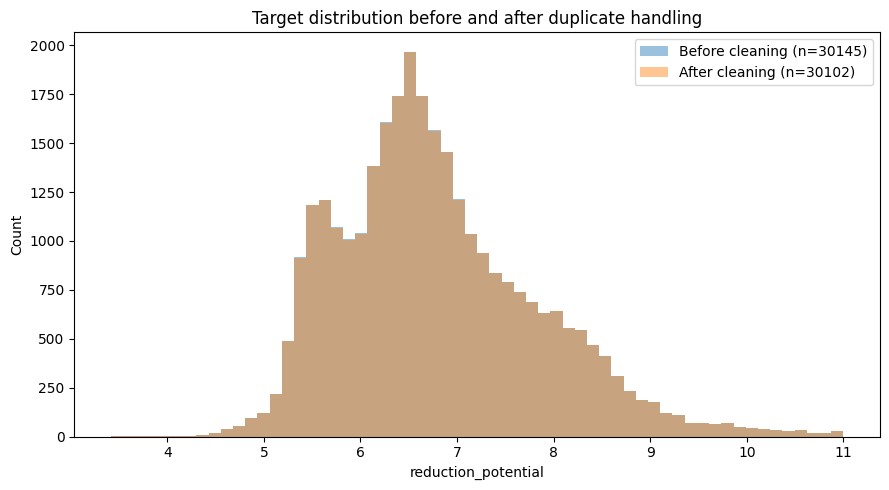

图片已保存: E:\desktop\myJCIM\reports\figures\d3tales_cleaning_comparison.png


In [11]:
# 使用相同的分箱边界对比清洗前后分布
bins = np.linspace(
    df_valid['reduction_potential'].min(),
    df_valid['reduction_potential'].max(),
    61,
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    df_valid['reduction_potential'], bins=bins, alpha=0.45,
    label=f'Before cleaning (n={len(df_valid)})'
)
ax.hist(
    df_clean['reduction_potential'], bins=bins, alpha=0.45,
    label=f'After cleaning (n={len(df_clean)})'
)
ax.set_xlabel('reduction_potential')
ax.set_ylabel('Count')
ax.set_title('Target distribution before and after duplicate handling')
ax.legend()
fig.tight_layout()

figure_path = REPORT_FIGURE_DIR / 'd3tales_cleaning_comparison.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()
print('图片已保存:', figure_path)

## 单元格 12：保存清洗数据和可追溯报告

作用：在全部自检通过后保存最终清洗数据、冲突记录、重复决策、数据流程和元数据。此单元格会覆盖同名的 V1 输出文件，但不会修改原始 CSV。

In [12]:
# 明确输出路径，方便本地和服务器使用同一套文件名
clean_path = PROCESSED_DIR / 'd3tales_reduction_neutral_v1.csv'
conflict_path = INTERIM_DIR / 'd3tales_conflicting_duplicates_v1.csv'
decision_path = REPORT_DATA_DIR / 'd3tales_duplicate_decisions_v1.csv'
flow_path = REPORT_DATA_DIR / 'd3tales_cleaning_flow_v1.csv'
metadata_path = REPORT_DATA_DIR / 'd3tales_cleaning_metadata_v1.json'

# 保存表格产物
df_clean.to_csv(clean_path, index=False)
conflict_rows.to_csv(conflict_path, index=False)
duplicate_stats.sort_values('target_range', ascending=False).to_csv(decision_path, index=False)
data_flow.to_csv(flow_path, index=False)

# 保存清洗参数和结果数量，保证之后能够复现同一数据版本
cleaning_metadata = {
    'dataset_version': DATASET_VERSION,
    'raw_file': str(RAW_CSV),
    'raw_sha256': raw_sha256,
    'target': 'reduction_potential',
    'neutral_charge': 0,
    'duplicate_tolerance_eV': DUPLICATE_TOLERANCE_EV,
    'duplicate_rule': 'average_if_range_le_tolerance_else_exclude_group',
    'raw_rows': int(len(df_raw)),
    'valid_candidate_rows': int(len(df_valid)),
    'accepted_duplicate_groups': int((duplicate_stats['decision'] == 'average_duplicate').sum()),
    'excluded_conflict_groups': int((duplicate_stats['decision'] == 'exclude_conflict').sum()),
    'excluded_conflict_rows': int(len(conflict_rows)),
    'final_unique_molecules': int(len(df_clean)),
    'unique_scaffolds_including_empty': int(df_clean['murcko_scaffold'].nunique(dropna=False)),
    'python_version': platform.python_version(),
    'pandas_version': pd.__version__,
    'rdkit_version': rdBase.rdkitVersion,
}
with metadata_path.open('w', encoding='utf-8') as file_handle:
    json.dump(cleaning_metadata, file_handle, ensure_ascii=False, indent=2)

print('清洗数据:', clean_path)
print('冲突记录:', conflict_path)
print('重复决策:', decision_path)
print('清洗流程:', flow_path)
print('清洗元数据:', metadata_path)

清洗数据: E:\desktop\myJCIM\data\processed\d3tales_reduction_neutral_v1.csv
冲突记录: E:\desktop\myJCIM\data\interim\d3tales_conflicting_duplicates_v1.csv
重复决策: E:\desktop\myJCIM\reports\data\d3tales_duplicate_decisions_v1.csv
清洗流程: E:\desktop\myJCIM\reports\data\d3tales_cleaning_flow_v1.csv
清洗元数据: E:\desktop\myJCIM\reports\data\d3tales_cleaning_metadata_v1.json


## 单元格 13：最终核对已保存文件

作用：从磁盘重新读取最终 CSV，确认保存后的行数、唯一性和目标值完整性。完成后请把本单元格输出和清洗对比图发给我。

In [13]:
# 重新读取磁盘文件，而不是继续信任内存中的 DataFrame
saved_clean = pd.read_csv(clean_path, low_memory=False)
assert len(saved_clean) == len(df_clean), '保存前后行数不一致'
assert saved_clean['canonical_smiles'].is_unique, '保存后Canonical SMILES不唯一'
assert saved_clean['reduction_potential'].notna().all(), '保存后存在缺失目标值'

final_summary = pd.Series({
    'saved_rows': len(saved_clean),
    'unique_canonical_smiles': saved_clean['canonical_smiles'].nunique(),
    'unique_scaffolds_including_empty': saved_clean['murcko_scaffold'].nunique(dropna=False),
    'averaged_duplicate_groups': saved_clean['cleaning_action'].eq('averaged_duplicate').sum(),
    'excluded_conflict_groups': len(conflict_smiles),
    'target_mean': saved_clean['reduction_potential'].mean(),
    'target_std': saved_clean['reduction_potential'].std(),
    'target_min': saved_clean['reduction_potential'].min(),
    'target_max': saved_clean['reduction_potential'].max(),
})
final_summary

saved_rows                          30102.000000
unique_canonical_smiles             30102.000000
unique_scaffolds_including_empty    15956.000000
averaged_duplicate_groups              12.000000
excluded_conflict_groups               15.000000
target_mean                             6.799163
target_std                              1.039974
target_min                              3.418000
target_max                             11.000000
dtype: float64